# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?
2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.
3. True or false, and explain: Logistic regression is a linear model.
4. True or false, and explain: Logistic regression cannot be used for classification.
5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?
6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.
7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

1 -  general linear models/latent variable models/ activation functions let us to model nonlinear relationships by transforming the output of a linear model which means we get the computational simplicity of linear models while being able to capture some more complex paterns in data
2 -  cross entropy penalizes confident wrong predictions very heavily (v the log) which is exactly what you want for a probability output- it pushes the model to assign high probability to the right class and low prob to the wrong one making it a natural fit for logistic regressions 0/1 output.
3 - True and false? — logistic regression is linear in the log odds (the latent variable $b_0 + b_1x$ is a linear function of the features), but the predicted probabilities are a nonlinear transformation of that linear combination v the sigmoid function
4 - false - logistic regression is actually widely used for classification by thresholding the predicted probability (ex predict class 1 if p> 0.5), even though it technically outputs a continuous prob.
5 -  No — the coefficient represents the change in the log odds for a 1 unit change in the feature- not the predicted probability directly bc the relationship between the feature and the predicted probability is nonlinear
6 - false-  even tho logistic regression applies a nonlinear transformation to the output the decision boundary is still linear in the feature space, so feature engineering (ex polynomial features, interactions) is still necessary to capture nonlinear relationships between features and outcome
7 - false — logistic regression is better suited for binary outcomes since it models probs that are bounded between 0 and 1, but ols is perfectly appropriate for continuous outcomes, so the choice depends on the nature of your target variable rather than one always being superior

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


Missing values per column:
Debtor                                 0
Tuition fees up to date                0
Scholarship holder                     0
Age at enrollment                      0
Curricular units 1st sem (approved)    0
Target                                 0
dtype: int64

Total rows before dropping: 4424
Total rows after dropping: 4424

Target distribution:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Binary dropout distribution:
dropout
0    3003
1    1421
Name: count, dtype: int64
                Feature  Coefficient
                 Debtor     0.530625
      Age at enrollment     0.049925
     Scholarship holder    -1.227442
Tuition fees up to date    -2.556542

Intercept: 0.4857


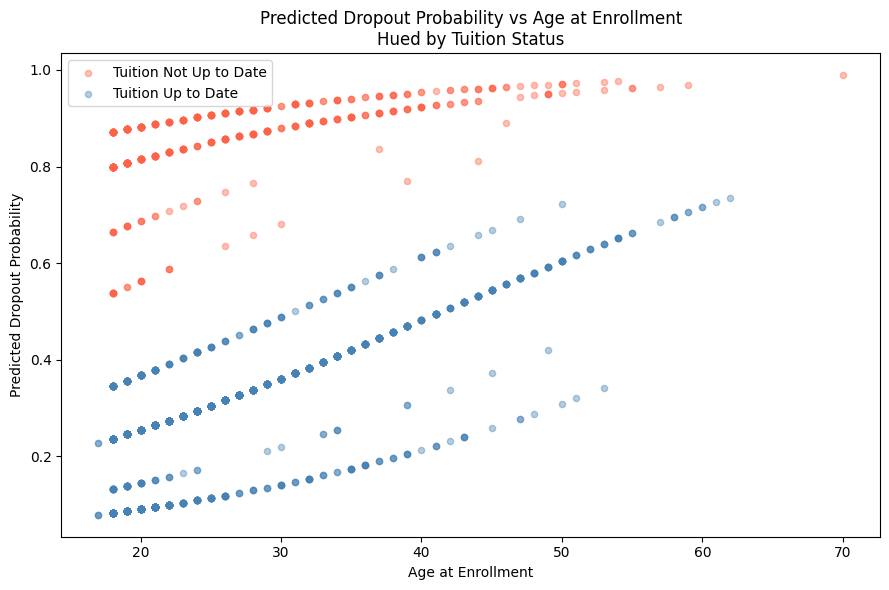

Avg dropout probability (tuition up to date):     0.2481
Avg dropout probability (tuition NOT up to date): 0.8607
Average difference:                               0.6126

Age where tuition gap is largest:
Age 19 — gap of 0.6175


/var/folders/xj/pd7w9qz52gq4znklqy7h1rqh0000gn/T/ipykernel_80488/2155754108.py:76: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  age_gap = df.groupby('Age at enrollment').apply(


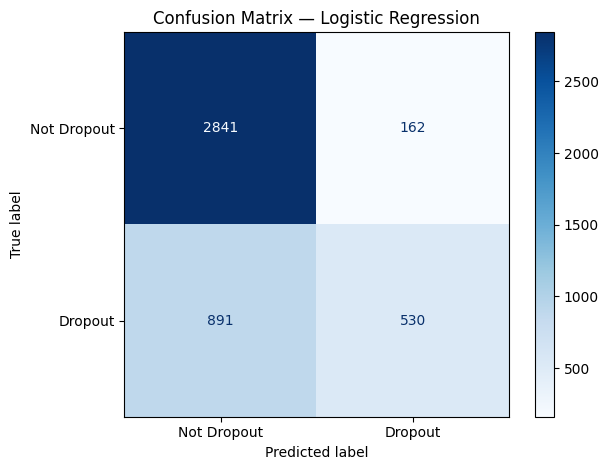

Accuracy: 0.7620 (76.20%)


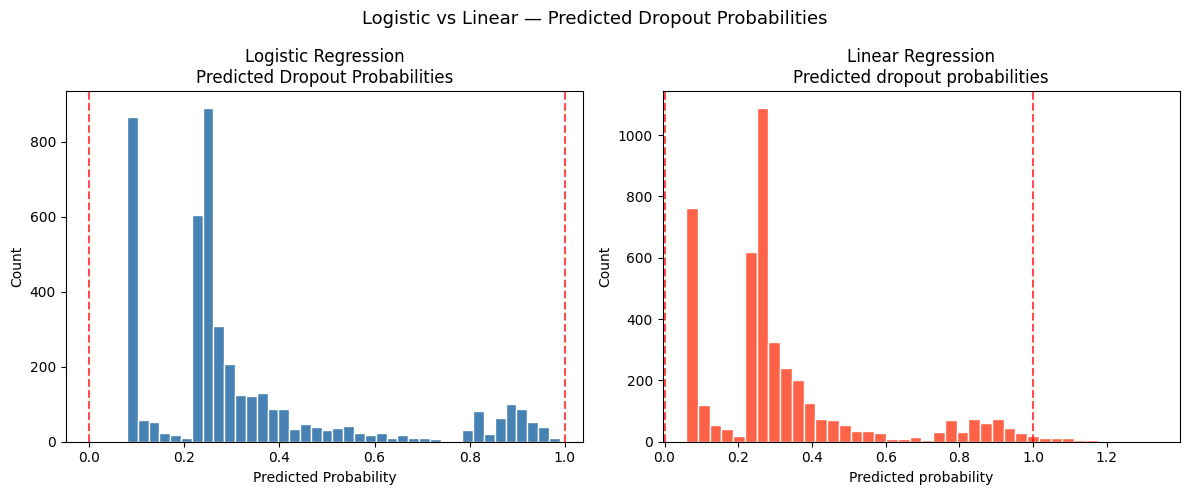

Logistic Regression accuracy: 0.7620
Linear regression accuracy:   0.7633

Linear model predicted probabilities outside [0,1]:
57 students (1.3%)
Min predicted probability: 0.0583
Max predicted probability- 1.3350


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


=== Hard Classification ===
Classes predicted: ['Dropout' 'Graduate']
Accuracy: 0.7046


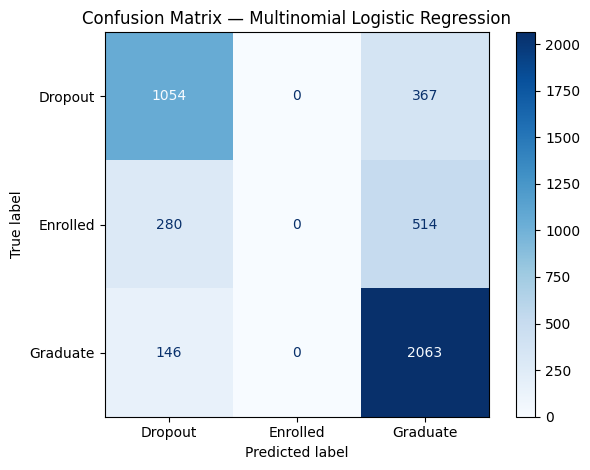


=== Predicted Probabilities (first 10 rows) ===
 Dropout  Enrolled  Graduate
0.680547  0.210464  0.108989
0.695414  0.146043  0.158543
0.952988  0.041199  0.005813
0.117808  0.176983  0.705209
0.184227  0.212669  0.603104
0.308421  0.323433  0.368146
0.071938  0.140644  0.787418
0.952988  0.041199  0.005813
0.117808  0.176983  0.705209
0.838886  0.122977  0.038136

Mean predicted probability per class:
Dropout     0.321223
Enrolled    0.179474
Graduate    0.499303
dtype: float64

Classes with nonzero predicted probabilities: ['Dropout', 'Enrolled', 'Graduate']


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# 1

df = pd.read_csv('data/data.csv', delimiter=';')
cols = ['Debtor', 'Tuition fees up to date', 'Scholarship holder',
        'Age at enrollment', 'Curricular units 1st sem (approved)', 'Target']
df = df[cols]

# check for missing values and record them
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal rows before dropping: {len(df)}") # current data

# drop missing values
df = df.dropna()
print(f"Total rows after dropping: {len(df)}") # new # rows (turned out to be the same, nothjing missing)

df['dropout'] = (df['Target'] == 'Dropout').astype(int)

print(f"\nTarget distribution:")
print(df['Target'].value_counts())
print(f"\nBinary dropout distribution:")
print(df['dropout'].value_counts())

# 2 
features = ['Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment']
X = df[features]
y = df['dropout']

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X, y)

coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': log_reg.coef_[0]
}).sort_values('Coefficient', ascending=False)

print(coef_df.to_string(index=False))
print(f"\nIntercept: {log_reg.intercept_[0]:.4f}")
# tutition up to date and scholarship holders are negatively associated with dropping out - this makes sense,
# financial stability is important to keep a studnet enrolled
# being a debtor and age of enrollment show to be positivley associated with dropping out, also makes sense as 
# life and financial responsibilities can make it difficult to stay in higher education
# for example, yes, being up to date with tuition seems to decrease dropout risk

# 3
df['dropout_prob'] = log_reg.predict_proba(X)[:, 1]

fig, ax = plt.subplots(figsize=(9, 6))

for tuition_status, group in df.groupby('Tuition fees up to date'):
    label = 'Tuition Up to Date' if tuition_status == 1 else 'Tuition Not Up to Date'
    color = 'steelblue' if tuition_status == 1 else 'tomato'
    ax.scatter(group['Age at enrollment'], group['dropout_prob'],
               label=label, color=color, alpha=0.4, s=20)

ax.set_xlabel('Age at Enrollment')
ax.set_ylabel('Predicted Dropout Probability')
ax.set_title('Predicted Dropout Probability vs Age at Enrollment\nHued by Tuition Status')
ax.legend()
plt.tight_layout()
plt.show()

avg_prob_tuition    = df[df['Tuition fees up to date'] == 1]['dropout_prob'].mean()
avg_prob_no_tuition = df[df['Tuition fees up to date'] == 0]['dropout_prob'].mean()
avg_diff            = avg_prob_no_tuition - avg_prob_tuition

print(f"Avg dropout probability (tuition up to date):     {avg_prob_tuition:.4f}")
print(f"Avg dropout probability (tuition NOT up to date): {avg_prob_no_tuition:.4f}")
print(f"Average difference:                               {avg_diff:.4f}")

age_gap = df.groupby('Age at enrollment').apply(
    lambda g: g[g['Tuition fees up to date'] == 0]['dropout_prob'].mean() -
              g[g['Tuition fees up to date'] == 1]['dropout_prob'].mean()
).dropna()

print(f"\nAge where tuition gap is largest:")
print(f"Age {age_gap.idxmax()} — gap of {age_gap.max():.4f}")
# for being up to date on tuition, it seems that the younger the age, the more reduced the dropout probability
#, seemingly the lowest around ages 18-20.
# being up to date on tuition decreases the probability of dropping out by around 61%, which is significantly high.

# 4
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

y_pred = log_reg.predict(X)

cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Dropout', 'Dropout'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Logistic Regression')
plt.tight_layout()
plt.show()

# Accuracy
accuracy = accuracy_score(y, y_pred)
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
# Accuracy: 0.7620 (76.20%)

# 5 

from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y)

df['dropout_prob_linear'] = lin_reg.predict(X)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df['dropout_prob'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Logistic Regression\nPredicted Dropout Probabilities')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Count')
axes[0].axvline(0, color='red', linestyle='--', alpha=0.7)
axes[0].axvline(1, color='red', linestyle='--', alpha=0.7)

axes[1].hist(df['dropout_prob_linear'], bins=40, color='tomato', edgecolor='white')
axes[1].set_title('Linear Regression\nPredicted dropout probabilities')
axes[1].set_xlabel('Predicted probability')
axes[1].set_ylabel('Count')
axes[1].axvline(0, color='red', linestyle='--', alpha=0.7)
axes[1].axvline(1, color='red', linestyle='--', alpha=0.7)

plt.suptitle('Logistic vs Linear — Predicted Dropout Probabilities', fontsize=13)
plt.tight_layout()
plt.show()

y_pred_linear = (df['dropout_prob_linear'] >= 0.5).astype(int)
acc_linear  = accuracy_score(y, y_pred_linear)
acc_logistic = accuracy_score(y, y_pred)

print(f"Logistic Regression accuracy: {acc_logistic:.4f}")
print(f"Linear regression accuracy:   {acc_linear:.4f}")

print(f"\nLinear model predicted probabilities outside [0,1]:")
out_of_range = df[(df['dropout_prob_linear'] < 0) | (df['dropout_prob_linear'] > 1)]
print(f"{len(out_of_range)} students ({len(out_of_range)/len(df)*100:.1f}%)")
print(f"Min predicted probability: {df['dropout_prob_linear'].min():.4f}")
print(f"Max predicted probability- {df['dropout_prob_linear'].max():.4f}")
# Comparing Performance:
# Logistic Regression accuracy: 0.7620
# Linear regression accuracy:   0.7633
# Linear model predicted probabilities outside [0,1]:
# 57 students (1.3%)
# Min predicted probability: 0.0583
# Max predicted probability- 1.3350

# Also 5
# Based on all of this, the students that are most likely to drop out are older students, and students who don't
# have tuition payments up to date. The oldest group without tuition up to date is the most at risk of dropping out.
# This is a difficult problem to solve - to combat it, better financial aid systems could be introduced, and 
# recieved aid could possibly increase with age. Education systems about financial literacy/loan literacy
# could be offered, to help students better understand how to handle their own finances. Students in the high-risk
# dropout demographic could also be flagged, and offered extra guidance/counseling.

# 7
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

features_multi = ['Debtor', 'Tuition fees up to date', 'Curricular units 1st sem (approved)']
X_multi = df[features_multi]
y_multi = df['Target']

multi_log_reg = LogisticRegression(multi_class='multinomial', max_iter=1000, random_state=42)
multi_log_reg.fit(X_multi, y_multi)

y_pred_multi = multi_log_reg.predict(X_multi)

print("=== Hard Classification ===")
print(f"Classes predicted: {np.unique(y_pred_multi)}")
print(f"Accuracy: {accuracy_score(y_multi, y_pred_multi):.4f}")

cm_multi = confusion_matrix(y_multi, y_pred_multi, labels=['Dropout', 'Enrolled', 'Graduate'])
disp_multi = ConfusionMatrixDisplay(confusion_matrix=cm_multi,
                                     display_labels=['Dropout', 'Enrolled', 'Graduate'])
disp_multi.plot(cmap='Blues')
plt.title('Confusion Matrix — Multinomial Logistic Regression')
plt.tight_layout()
plt.show()

y_proba_multi = multi_log_reg.predict_proba(X_multi)

proba_df = pd.DataFrame(y_proba_multi, columns=multi_log_reg.classes_)
print("\n=== Predicted Probabilities (first 10 rows) ===")
print(proba_df.head(10).to_string(index=False))
print(f"\nMean predicted probability per class:")
print(proba_df.mean())
print(f"\nClasses with nonzero predicted probabilities: {proba_df.columns[(proba_df > 0).any()].tolist()}")

#The hard classification likely never predicts "Enrolled" since those students are ambiguous
# they haven't finished or left, so the model never pushes them past the 0.5 threshold
# The predicted probabilities however assign nonzero probability to all three classes for every student, 
# preserving uncertainty that hard classification throws away
# for example a student with (0.31, 0.32, 0.37) gets labeled Graduate even though the model is essentially uncertain, 
# making .predict_proba far more useful in practice.

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics 
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class? 

Missing values per column:
Bilirubin      0
Edema          0
Drug         106
Stage          6
Status         0
dtype: int64

Total rows before dropping: 418
Total rows after dropping: 312
=== Coefficients per class ===
    Bilirubin     Edema      Drug
C   -0.273060 -0.711629 -0.143309
CL   0.090944 -0.299187  0.034397
D    0.182116  1.010817  0.108912

Intercepts: [ 1.59460135 -1.44970995 -0.1448914 ]


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


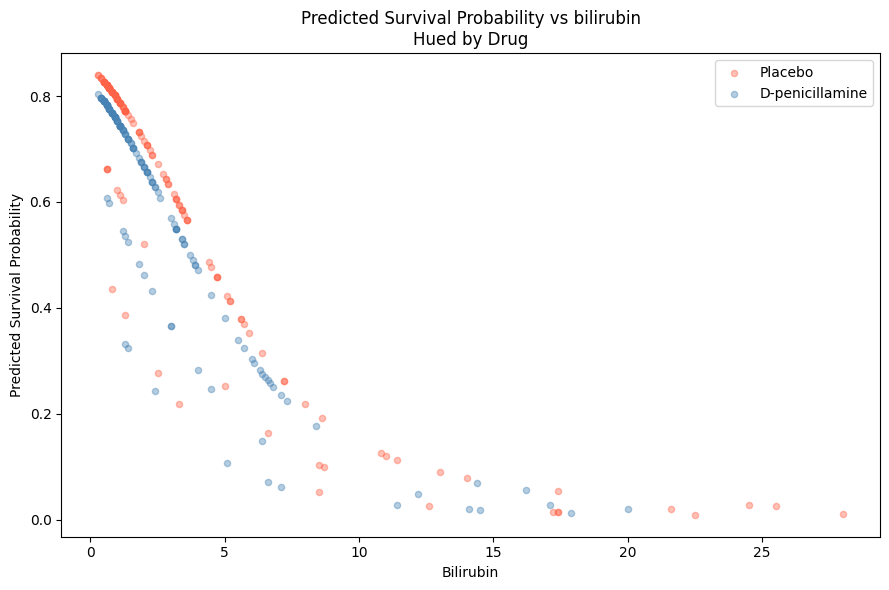

Avg survival probability (D-penicillamine): 0.5892
Avg survival probability (Placebo):         0.6098
Average difference:                         -0.0206

Bilirubin range where drug benefit is largest:
(5.84, 8.61] — gap of 0.0087


/var/folders/xj/pd7w9qz52gq4znklqy7h1rqh0000gn/T/ipykernel_80488/2503132071.py:71: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bilirubin_gap = df.groupby('bilirubin_bin').apply(
/var/folders/xj/pd7w9qz52gq4znklqy7h1rqh0000gn/T/ipykernel_80488/2503132071.py:71: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bilirubin_gap = df.groupby('bilirubin_bin').apply(


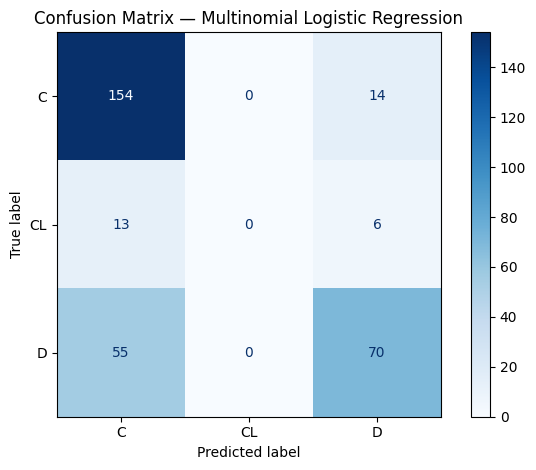

Accuracy: 0.7179 (71.79%)

Classes predicted: ['C' 'D']


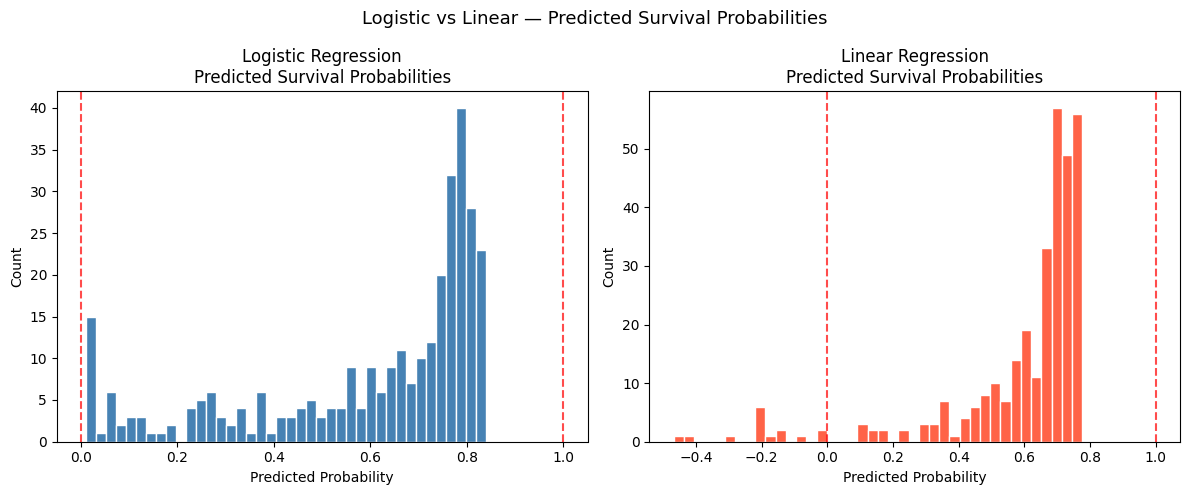

Logistic Regression Accuracy: 0.7564
Linear Regression Accuracy:   0.7276

Linear model out-of-range predictions:
15 patients (4.8%)
Min: -0.4678
Max: 0.7757
=== Hard Classification ===
Classes in data:      [1. 2. 3. 4.]
Classes predicted:    [3. 4.]
Accuracy: 0.4391


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


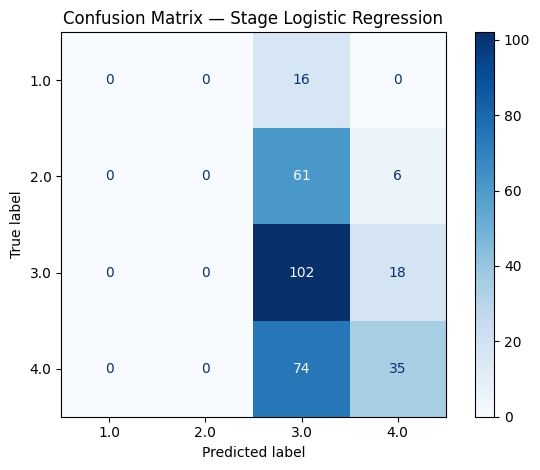


=== Predicted Probabilities (first 10 rows) ===
     1.0      2.0      3.0      4.0
0.000008 0.030941 0.173328 0.795722
0.071716 0.251794 0.400914 0.275576
0.041597 0.182450 0.335665 0.440288
0.033123 0.178019 0.337582 0.451276
0.019958 0.225419 0.427181 0.327442
0.084127 0.253617 0.394748 0.267508
0.075655 0.252465 0.398951 0.272930
0.109143 0.255225 0.382496 0.253136
0.022367 0.228214 0.425979 0.323441
0.000027 0.038158 0.185122 0.776692

Mean predicted probability per class:
1.0    0.051285
2.0    0.214768
3.0    0.384592
4.0    0.349355
dtype: float64

Classes with nonzero predicted probabilities: [1.0, 2.0, 3.0, 4.0]


In [ ]:
# 1
df = pd.read_csv('data/cirrhosis.csv')

cols = ['Bilirubin', 'Edema', 'Drug', 'Stage', 'Status']
df = df[cols]

# checking for missing values and record them
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal rows before dropping: {len(df)}") # current data

# drop the missing values
df = df.dropna()
print(f"Total rows after dropping: {len(df)}") # drug had 106 missing, started w 418 rows, dropped to 312 when clean

# 2
df['Edema'] = df['Edema'].map({'N': 0, 'S': 0.5, 'Y': 1})
df['Drug']  = df['Drug'].map({'D-penicillamine': 1, 'Placebo': 0})

features = ['Bilirubin', 'Edema', 'Drug']
X = df[features]
y = df['Status']  # keep 3-class

log_reg = LogisticRegression(multi_class='multinomial', max_iter=1000, random_state=42)
log_reg.fit(X, y)

coef_df = pd.DataFrame(
    log_reg.coef_,
    columns=features,
    index=log_reg.classes_
)

print("=== Coefficients per class ===")
print(coef_df.to_string())
print(f"\nIntercepts: {log_reg.intercept_}")
# across all three features, the death coefficent is slightly positive, indicating that edema, bilirubin, and 
# drug are all actually associated with a higher death probability (higher bilirubin associated with 
# higher death prob). Edema has the highest coefficent, meaning it is the highest associated with death, higher 
# edema corresponding to higher prob of death. 

# 3
proba = log_reg.predict_proba(X)
proba_df = pd.DataFrame(proba, columns=log_reg.classes_)

df['survival_prob'] = 1 - proba_df['D']

fig, ax = plt.subplots(figsize=(9, 6))

for drug_status, group in df.groupby('Drug'):
    label = 'D-penicillamine' if drug_status == 1 else 'Placebo'
    color = 'steelblue' if drug_status == 1 else 'tomato'
    ax.scatter(group['Bilirubin'], group['survival_prob'],
               label=label, color=color, alpha=0.4, s=20)

ax.set_xlabel('Bilirubin')
ax.set_ylabel('Predicted Survival Probability')
ax.set_title('Predicted Survival Probability vs bilirubin\nHued by Drug')
ax.legend()
plt.tight_layout()
plt.show()

avg_survival_drug    = df[df['Drug'] == 1]['survival_prob'].mean()
avg_survival_placebo = df[df['Drug'] == 0]['survival_prob'].mean()
avg_diff             = avg_survival_drug - avg_survival_placebo

print(f"Avg survival probability (D-penicillamine): {avg_survival_drug:.4f}")
print(f"Avg survival probability (Placebo):         {avg_survival_placebo:.4f}")
print(f"Average difference:                         {avg_diff:.4f}")

df['bilirubin_bin'] = pd.cut(df['Bilirubin'], bins=10)
bilirubin_gap = df.groupby('bilirubin_bin').apply(
    lambda g: g[g['Drug'] == 1]['survival_prob'].mean() -
              g[g['Drug'] == 0]['survival_prob'].mean()
).dropna()

print(f"\nBilirubin range where drug benefit is largest:")
print(f"{bilirubin_gap.idxmax()} — gap of {bilirubin_gap.max():.4f}")
# Bilirubin range where drug benefit is largest: (5.84, 8.61] gap of 0.0087
# Avg survival probability (D-penicillamine): 0.5892
# Avg survival probability (Placebo): 0.6098
#Average difference: -0.0206

# 4
y_pred = log_reg.predict(X)

cm = confusion_matrix(y, y_pred, labels=['C', 'CL', 'D'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['C', 'CL', 'D'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Multinomial Logistic Regression')
plt.tight_layout()
plt.show()

accuracy = accuracy_score(y, y_pred)
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

print(f"\nClasses predicted: {np.unique(y_pred)}")
#Accuracy: 0.7179 (71.79%)
#Classes predicted: ['C' 'D']

#5
from sklearn.linear_model import LinearRegression
df['survival_binary'] = (df['Status'] != 'D').astype(int)

lin_reg = LinearRegression()
lin_reg.fit(X, df['survival_binary'])
df['survival_prob_linear'] = lin_reg.predict(X)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df['survival_prob'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Logistic Regression\nPredicted Survival Probabilities')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Count')
axes[0].axvline(0, color='red', linestyle='--', alpha=0.7)
axes[0].axvline(1, color='red', linestyle='--', alpha=0.7)

axes[1].hist(df['survival_prob_linear'], bins=40, color='tomato', edgecolor='white')
axes[1].set_title('Linear Regression\nPredicted Survival Probabilities')
axes[1].set_xlabel('Predicted Probability')
axes[1].set_ylabel('Count')
axes[1].axvline(0, color='red', linestyle='--', alpha=0.7)
axes[1].axvline(1, color='red', linestyle='--', alpha=0.7)

plt.suptitle('Logistic vs Linear — Predicted Survival Probabilities', fontsize=13)
plt.tight_layout()
plt.show()

y_pred_linear = (df['survival_prob_linear'] >= 0.5).astype(int)
acc_linear   = accuracy_score(df['survival_binary'], y_pred_linear)
acc_logistic = accuracy_score(df['survival_binary'], (df['survival_prob'] >= 0.5).astype(int))

print(f"Logistic Regression Accuracy: {acc_logistic:.4f}")
print(f"Linear Regression Accuracy:   {acc_linear:.4f}")

print(f"\nLinear model out-of-range predictions:")
out_of_range = df[(df['survival_prob_linear'] < 0) | (df['survival_prob_linear'] > 1)]
print(f"{len(out_of_range)} patients ({len(out_of_range)/len(df)*100:.1f}%)")
print(f"Min: {df['survival_prob_linear'].min():.4f}")
print(f"Max: {df['survival_prob_linear'].max():.4f}")
# The logistic regression model was slightly more accurate, however, both model's performance were in a
# comparably close range
#Logistic Regression Accuracy: 0.7564
#Linear Regression Accuracy:   0.7276

# 6
features_stage = ['Edema', 'Bilirubin']
X_stage = df[features_stage]
y_stage = df['Stage']

log_reg_stage = LogisticRegression(multi_class='multinomial', max_iter=1000, random_state=42)
log_reg_stage.fit(X_stage, y_stage)

y_pred_stage = log_reg_stage.predict(X_stage)

print("=== Hard Classification ===")
print(f"Classes in data:      {np.unique(y_stage.values)}")
print(f"Classes predicted:    {np.unique(y_pred_stage)}")
print(f"Accuracy: {accuracy_score(y_stage, y_pred_stage):.4f}")

cm_stage = confusion_matrix(y_stage, y_pred_stage)
disp_stage = ConfusionMatrixDisplay(confusion_matrix=cm_stage,
                                     display_labels=log_reg_stage.classes_)
disp_stage.plot(cmap='Blues')
plt.title('Confusion Matrix — Stage Logistic Regression')
plt.tight_layout()
plt.show()

y_proba_stage = log_reg_stage.predict_proba(X_stage)
proba_stage_df = pd.DataFrame(y_proba_stage, columns=log_reg_stage.classes_)

print("\n=== Predicted Probabilities (first 10 rows) ===")
print(proba_stage_df.head(10).to_string(index=False))
print(f"\nMean predicted probability per class:")
print(proba_stage_df.mean())
print(f"\nClasses with nonzero predicted probabilities: {proba_stage_df.columns[(proba_stage_df > 0).any()].tolist()}")

# The hard classific prolly never predicts stages 1 or 2 since they are hard to distinguish with just 
# Edema and Bilirubin, the model defaults to the more common later stages- the predicted probabilities 
# however assign nonzero values to all four stages for every patient and preserving uncertainty that 
# hard classification throws away. The mean probabilities (stage 1: 5%, 2: 21%, 3: 38%, 4: 35%) reflect 
# that this dataset skews toward laterstage pateints


**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio? 

![alt text](IMG_0027.jpg)

![alt text](IMG_0028.jpg)

![alt text](IMG_0029.jpg)